In [2]:
import seaborn as sns
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
dataset = pd.read_excel('dataset/covid.xlsx')
# url = 'https://raw.githubusercontent.com/MachineLearnia/Python-Machine-Learning/master/Dataset/dataset.csv'
# dataset = pd.read_csv(url, index_col=0, encoding = "ISO-8859-1")

In [4]:
df = dataset.__deepcopy__()

In [5]:
df.shape

(5644, 111)

In [6]:
total_patient = df.shape[0]
print(total_patient)

5644


In [7]:
df.columns

Index(['Patient ID', 'Patient age quantile', 'SARS-Cov-2 exam result',
       'Patient addmited to regular ward (1=yes, 0=no)',
       'Patient addmited to semi-intensive unit (1=yes, 0=no)',
       'Patient addmited to intensive care unit (1=yes, 0=no)', 'Hematocrit',
       'Hemoglobin', 'Platelets', 'Mean platelet volume ',
       ...
       'Hb saturation (arterial blood gases)',
       'pCO2 (arterial blood gas analysis)',
       'Base excess (arterial blood gas analysis)',
       'pH (arterial blood gas analysis)',
       'Total CO2 (arterial blood gas analysis)',
       'HCO3 (arterial blood gas analysis)',
       'pO2 (arterial blood gas analysis)', 'Arteiral Fio2', 'Phosphor',
       'ctO2 (arterial blood gas analysis)'],
      dtype='object', length=111)

In [8]:
# df.drop(['Patient ID'], axis=1, inplace=True)
df.rename(columns={'Patient addmited to intensive care unit (1=yes, 0=no)': 'Intensive Care Unit'}, inplace=True)
df.rename(columns={'Patient addmited to regular ward (1=yes, 0=no)': 'Regular Care Unit'}, inplace=True)
df.rename(columns={'Patient addmited to semi-intensive unit (1=yes, 0=no)': 'Semi-Intensive Care Unit'}, inplace=True)
df.rename(columns={'SARS-Cov-2 exam result': 'covid'}, inplace=True)

<Axes: >

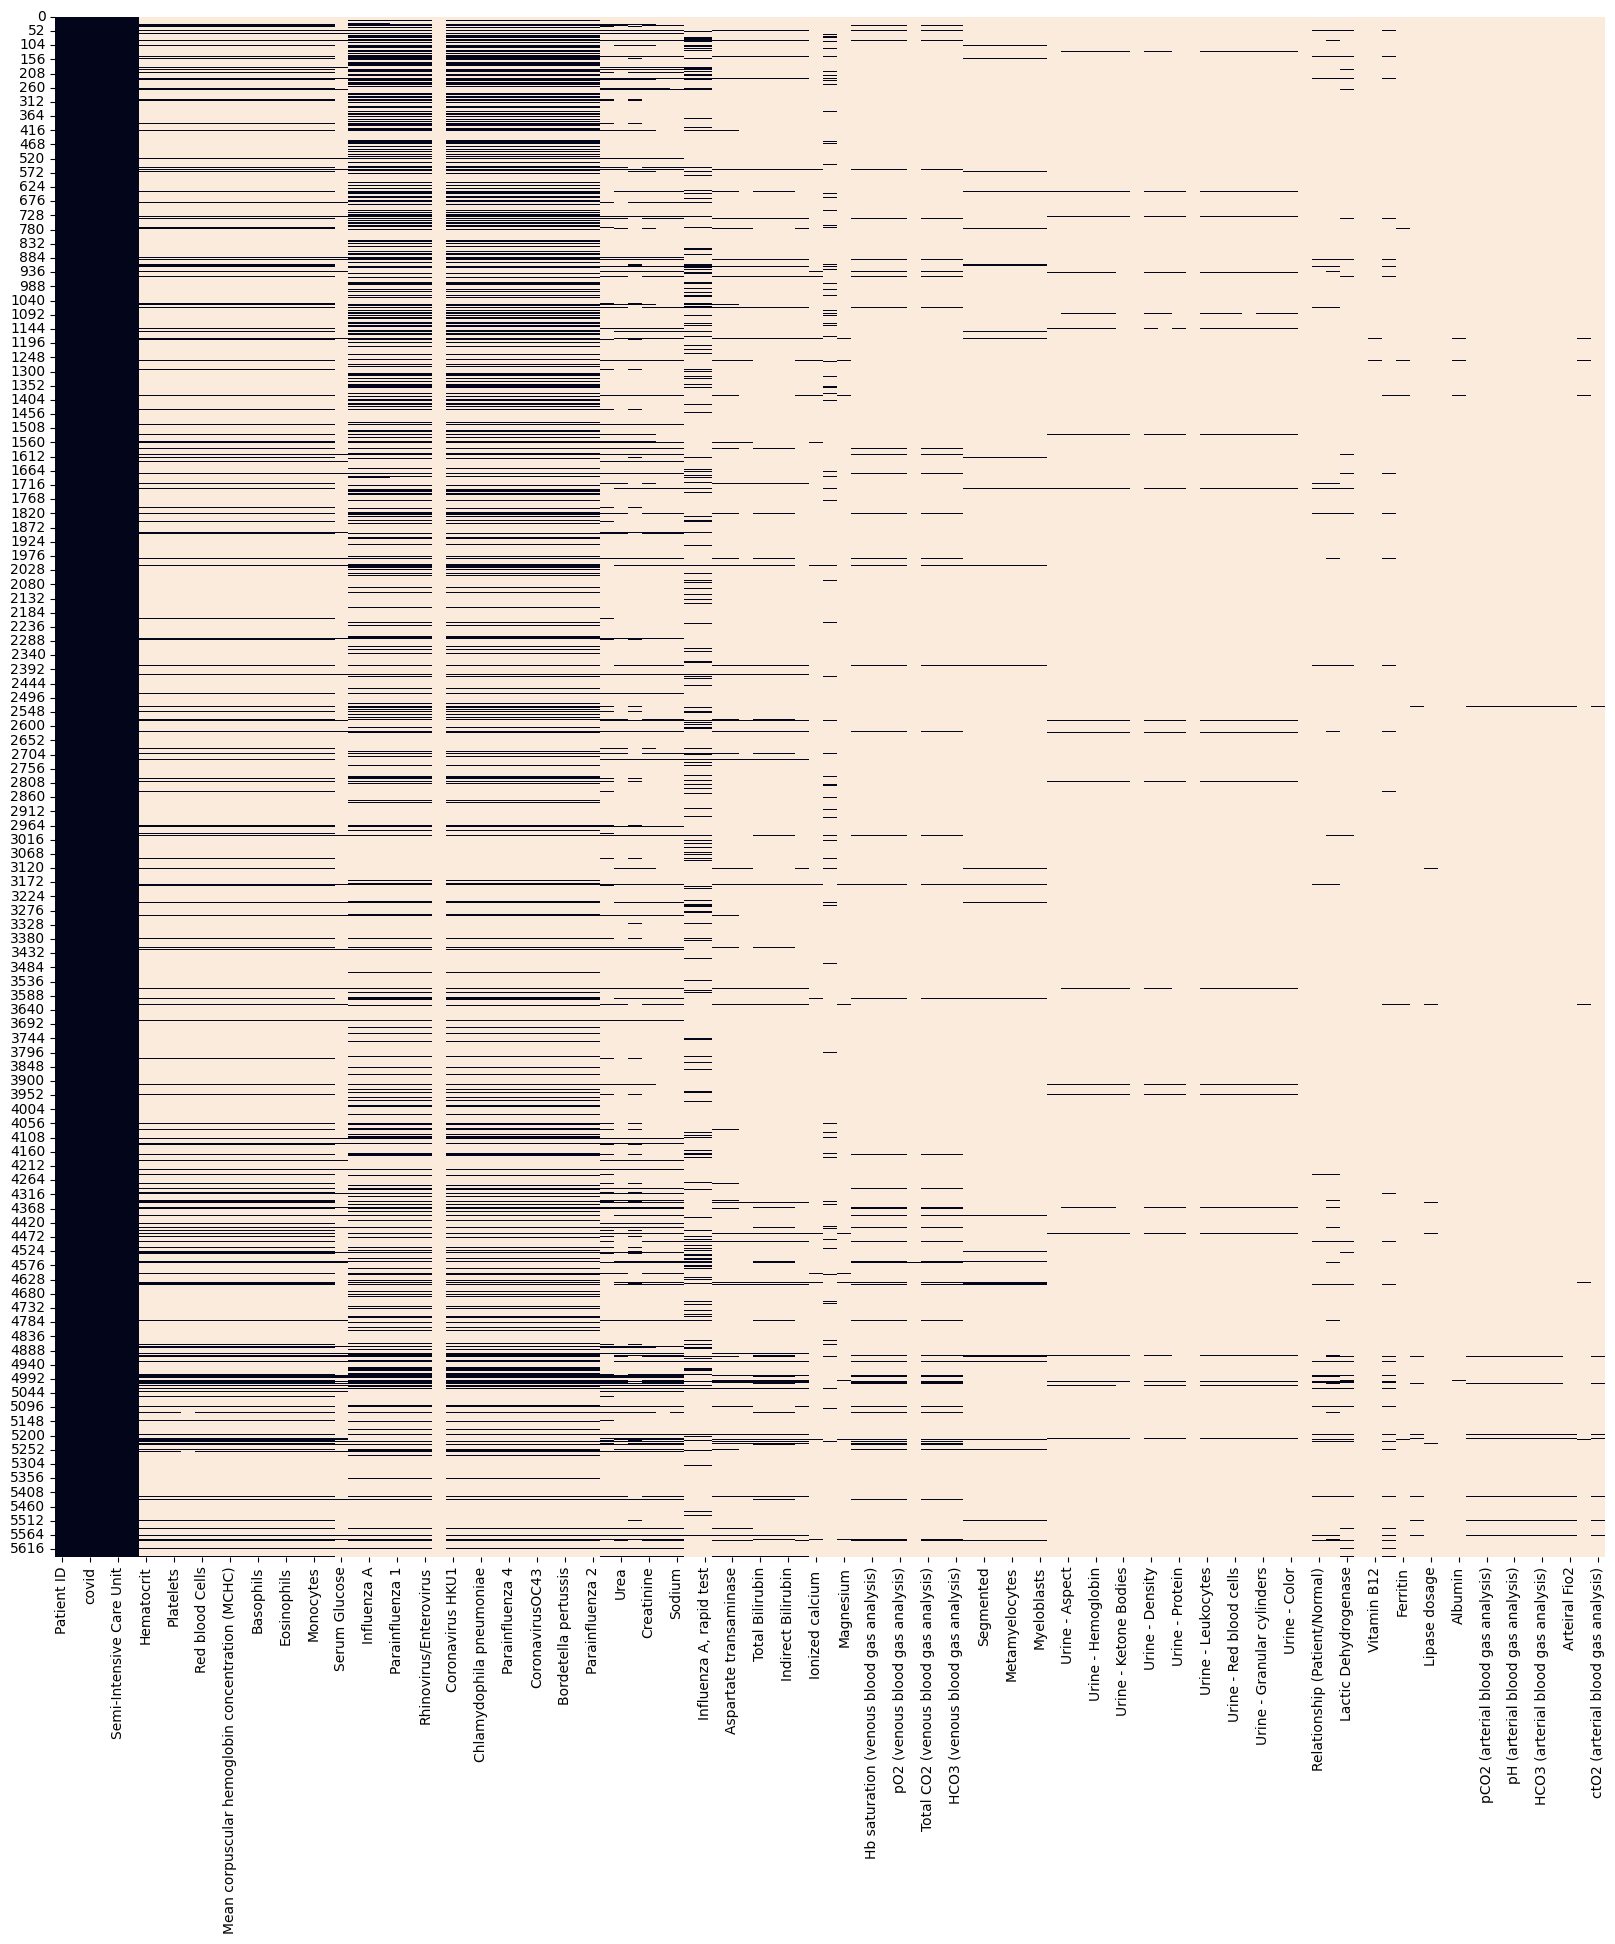

In [9]:
plt.figure(figsize=(20,20))
sns.heatmap(df.isna(), cbar=False)

In [10]:
missing_rates = df.isna().sum()/total_patient
missing_rates

Patient ID                            0.000000
Patient age quantile                  0.000000
covid                                 0.000000
Regular Care Unit                     0.000000
Semi-Intensive Care Unit              0.000000
                                        ...   
HCO3 (arterial blood gas analysis)    0.995216
pO2 (arterial blood gas analysis)     0.995216
Arteiral Fio2                         0.996456
Phosphor                              0.996456
ctO2 (arterial blood gas analysis)    0.995216
Length: 111, dtype: float64

In [11]:
new_columns = df.columns[missing_rates < 0.9]
new_columns

Index(['Patient ID', 'Patient age quantile', 'covid', 'Regular Care Unit',
       'Semi-Intensive Care Unit', 'Intensive Care Unit', 'Hematocrit',
       'Hemoglobin', 'Platelets', 'Mean platelet volume ', 'Red blood Cells',
       'Lymphocytes', 'Mean corpuscular hemoglobin concentration (MCHC)',
       'Leukocytes', 'Basophils', 'Mean corpuscular hemoglobin (MCH)',
       'Eosinophils', 'Mean corpuscular volume (MCV)', 'Monocytes',
       'Red blood cell distribution width (RDW)',
       'Respiratory Syncytial Virus', 'Influenza A', 'Influenza B',
       'Parainfluenza 1', 'CoronavirusNL63', 'Rhinovirus/Enterovirus',
       'Coronavirus HKU1', 'Parainfluenza 3', 'Chlamydophila pneumoniae',
       'Adenovirus', 'Parainfluenza 4', 'Coronavirus229E', 'CoronavirusOC43',
       'Inf A H1N1 2009', 'Bordetella pertussis', 'Metapneumovirus',
       'Parainfluenza 2', 'Influenza B, rapid test',
       'Influenza A, rapid test'],
      dtype='object')

In [12]:
df = df[new_columns]
df.head()

,Patient ID,Patient age quantile,covid,Regular Care Unit,Semi-Intensive Care Unit,Intensive Care Unit,Hematocrit,Hemoglobin,Platelets,Mean platelet volume,...,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2,"Influenza B, rapid test","Influenza A, rapid test"
0,44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,126e9dd13932f68,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,...,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,negative,negative
2,a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f7d619a94f97c45,5,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,d9e41465789c2b5,15,negative,0,0,0,NaN,NaN,NaN,NaN,...,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,NaN,NaN


<Axes: >

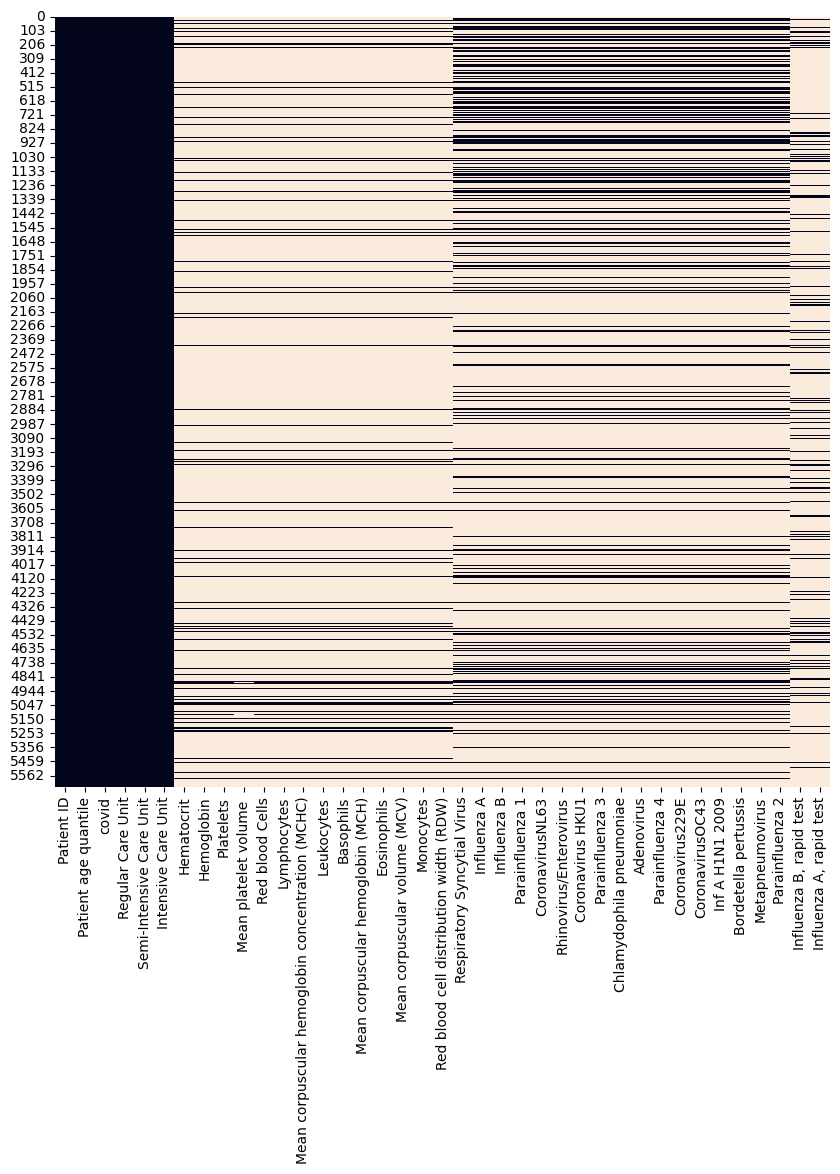

In [13]:
plt.figure(figsize=(10,10))
sns.heatmap(df.isna(), cbar=False)

In [14]:
df.dtypes.unique()

array([dtype('O'), dtype('int64'), dtype('float64')], dtype=object)

## Target Analysis

In [15]:
df['covid'].unique()

array(['negative', 'positive'], dtype=object)

In [16]:
print(df['covid'].value_counts())

covid
negative    5086
positive     558
Name: count, dtype: int64


<Axes: xlabel='covid', ylabel='Count'>

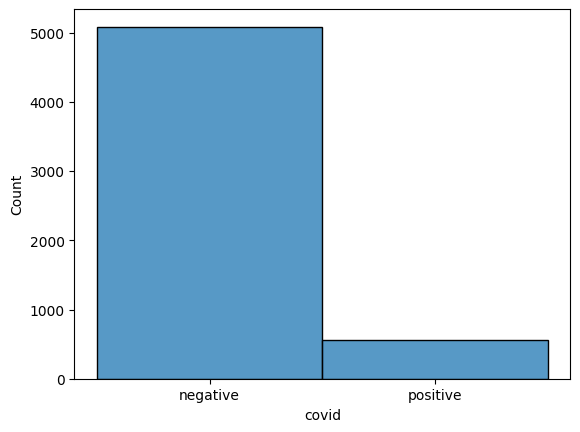

In [17]:
sns.histplot(df['covid'])

## Variable Quantitative

### Int: Age et unit

In [18]:
int_column_mask = df.dtypes == 'int'
int_df = df[df.columns[int_column_mask]].__deepcopy__()

In [19]:
int_df['Patient age quantile'].value_counts()

Patient age quantile
11    380
4     366
9     359
0     334
7     319
2     315
13    313
14    299
5     294
6     281
16    279
19    275
15    269
17    263
18    259
3     251
1     234
12    197
10    190
8     167
Name: count, dtype: int64

In [20]:
int_df[['Regular Care Unit', 'Intensive Care Unit', 'Semi-Intensive Care Unit']].value_counts()

Regular Care Unit  Intensive Care Unit  Semi-Intensive Care Unit
0                  0                    0                           5474
1                  0                    0                             79
0                  0                    1                             50
                   1                    0                             41
Name: count, dtype: int64

<Axes: xlabel='Patient age quantile', ylabel='Density'>

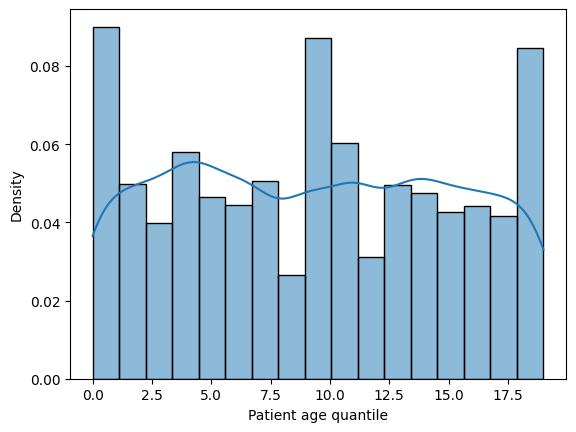

In [21]:
sns.histplot(int_df['Patient age quantile'], kde=True, stat='density')

<Axes: ylabel='Patient age quantile'>

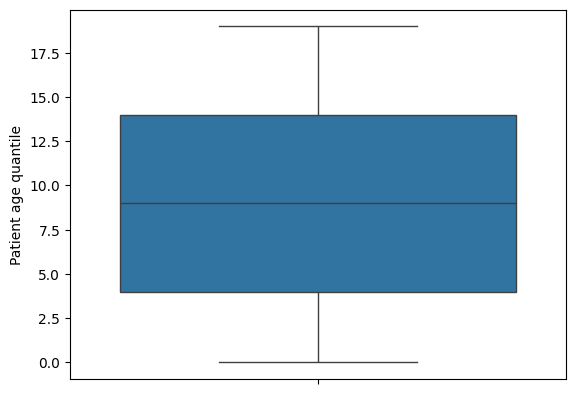

In [22]:
sns.boxplot(df['Patient age quantile'])

<Axes: xlabel='Patient age quantile', ylabel='count'>

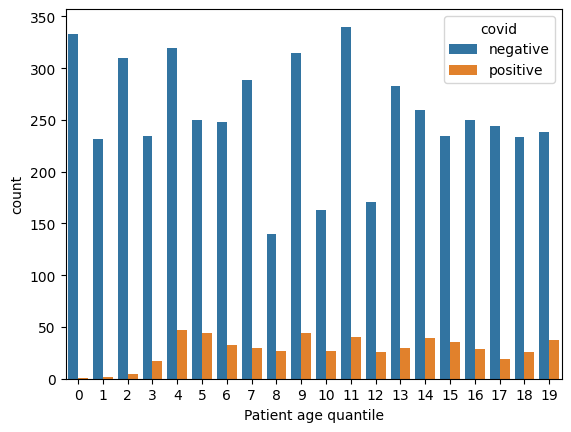

In [23]:
sns.countplot(data=df, x='Patient age quantile', hue='covid')

### Float: Blood analysis

In [24]:
float_column_mask = df.dtypes == 'float'
blood_df = df[df.columns[float_column_mask]].__deepcopy__()
print(blood_df.columns)

Index(['Hematocrit', 'Hemoglobin', 'Platelets', 'Mean platelet volume ',
       'Red blood Cells', 'Lymphocytes',
       'Mean corpuscular hemoglobin concentration (MCHC)', 'Leukocytes',
       'Basophils', 'Mean corpuscular hemoglobin (MCH)', 'Eosinophils',
       'Mean corpuscular volume (MCV)', 'Monocytes',
       'Red blood cell distribution width (RDW)'],
      dtype='object')


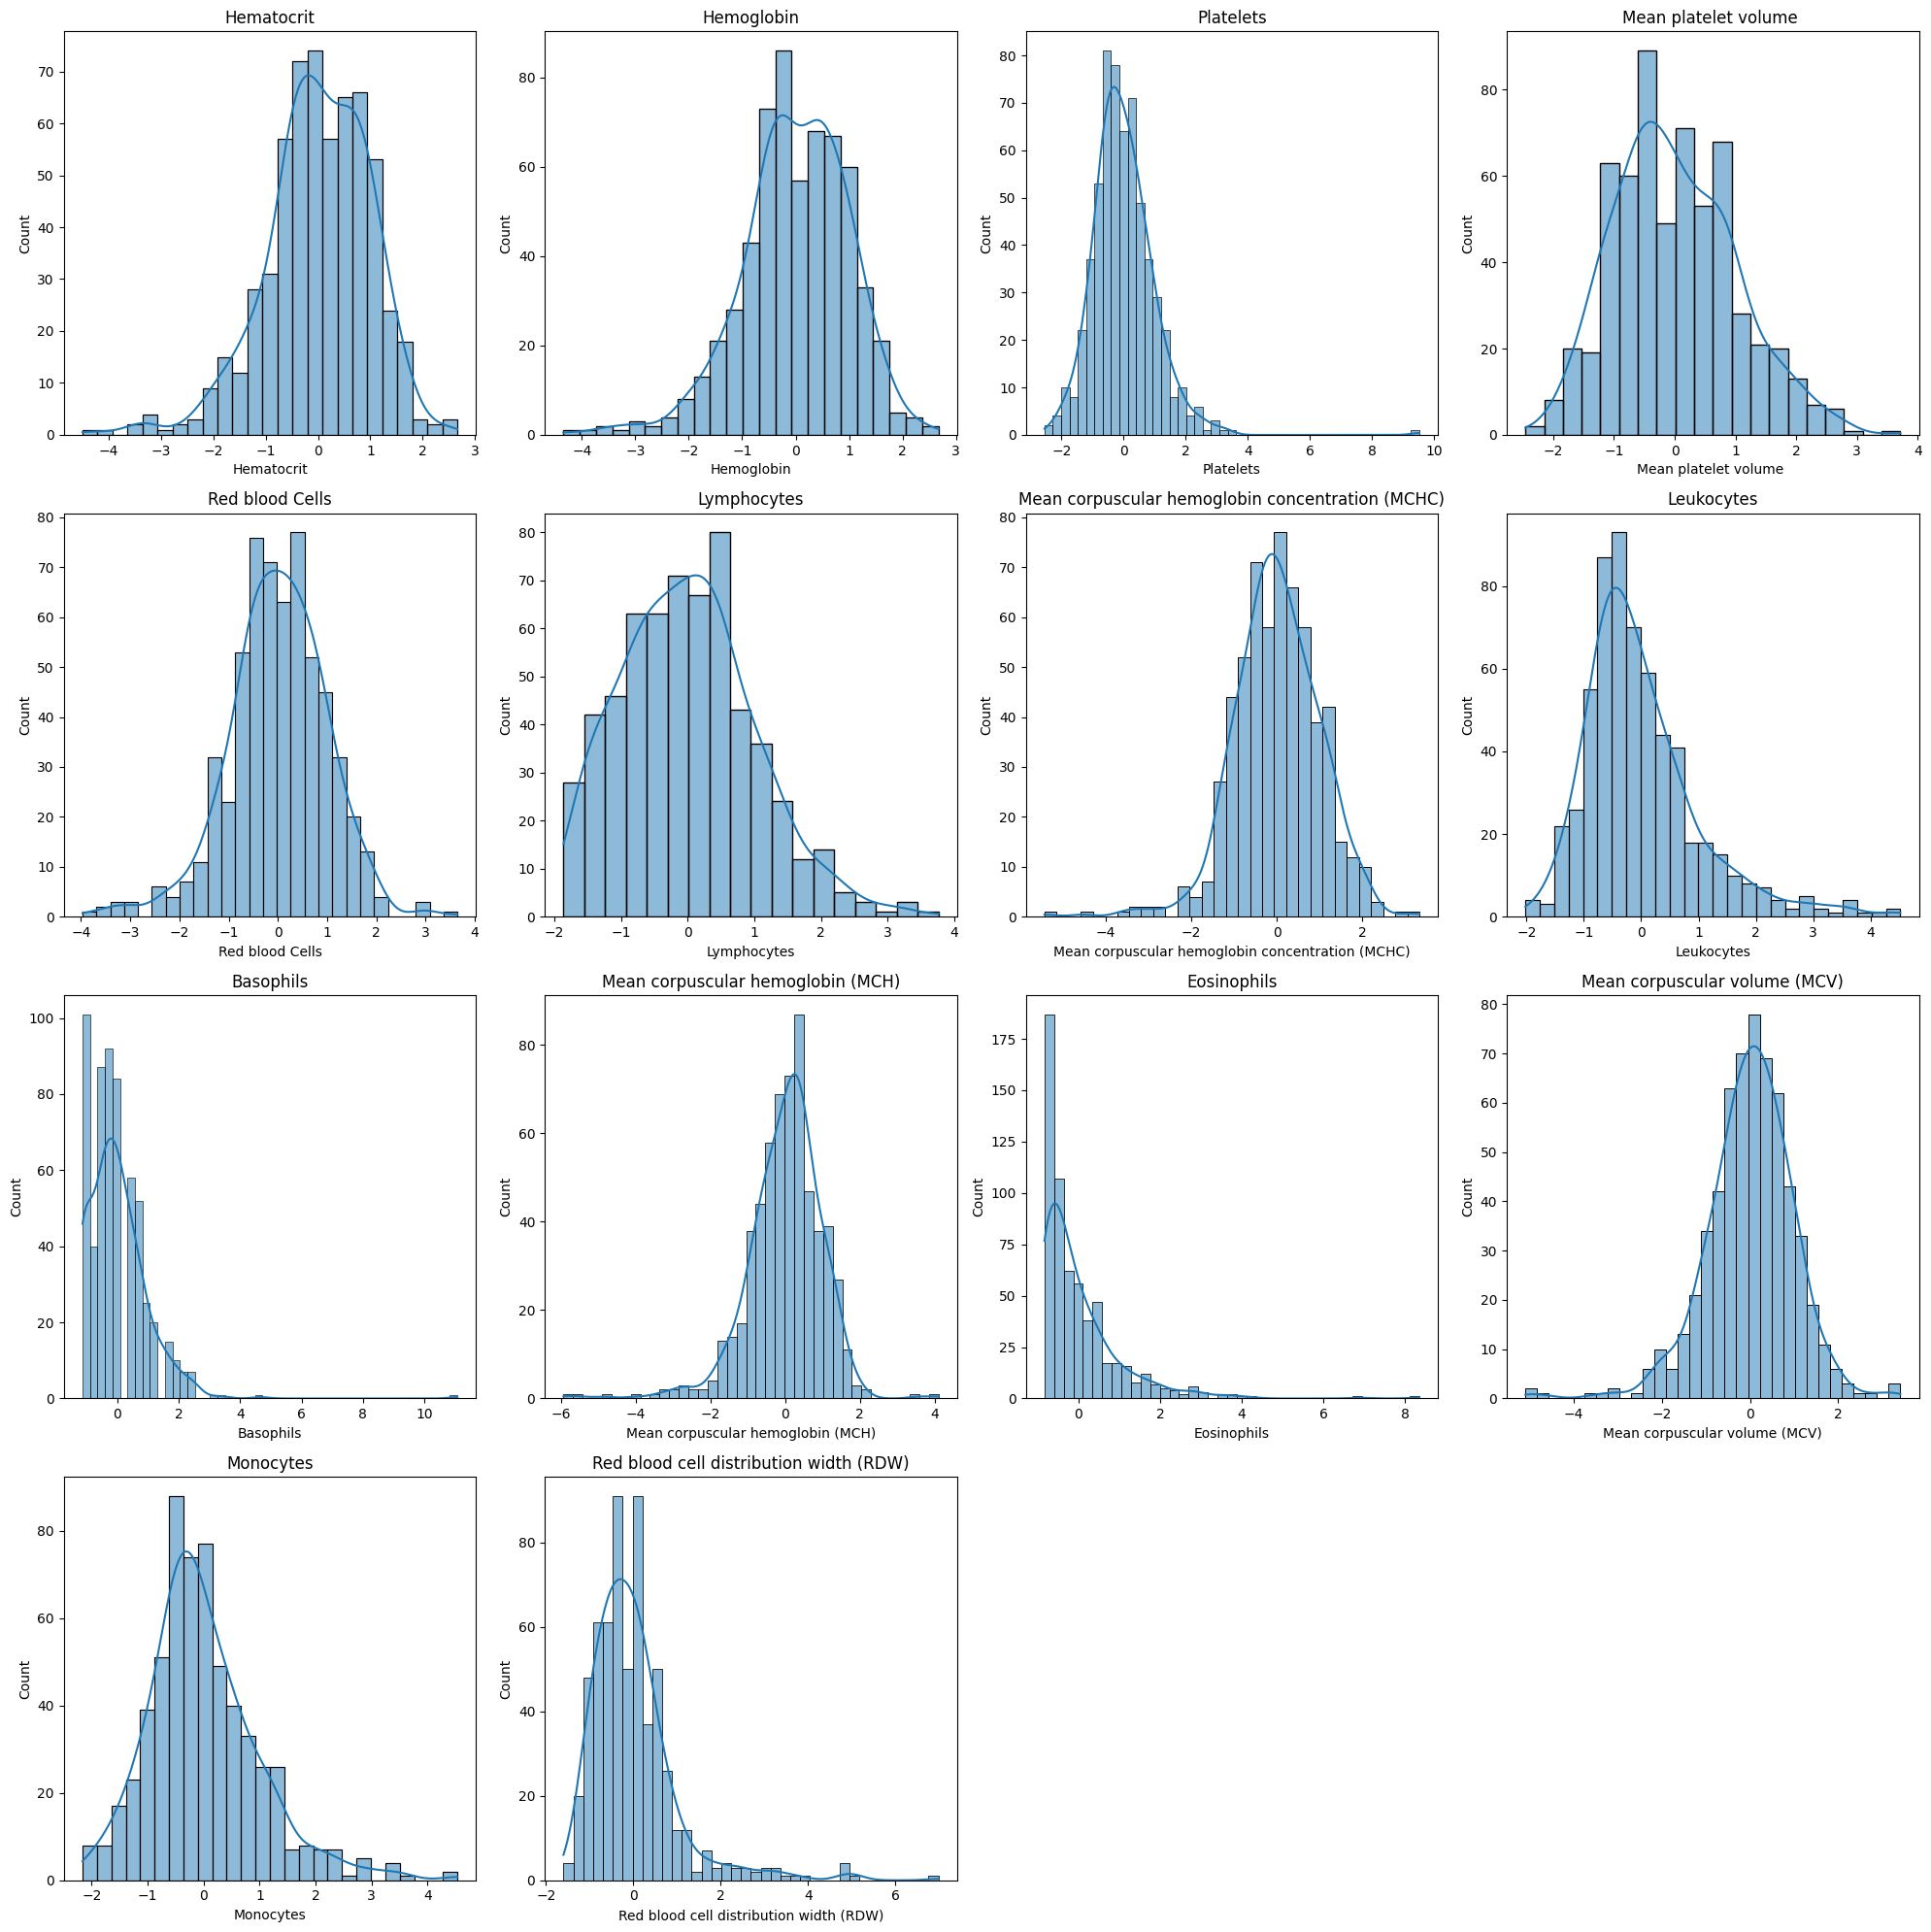

In [25]:
plt.figure(figsize=(20, 20))
for index, column in enumerate(blood_df.columns):
    plt.subplot(4, 4, index+1)
    sns.histplot(blood_df[column], kde=True)
    plt.title(column)
plt.tight_layout()

In [26]:
positive_covid_mask = df['covid']=='positive'
negative_covid_mask = df['covid']=='negative'
positive_df = df[positive_covid_mask].__deepcopy__()
negative_df = df[negative_covid_mask].__deepcopy__()

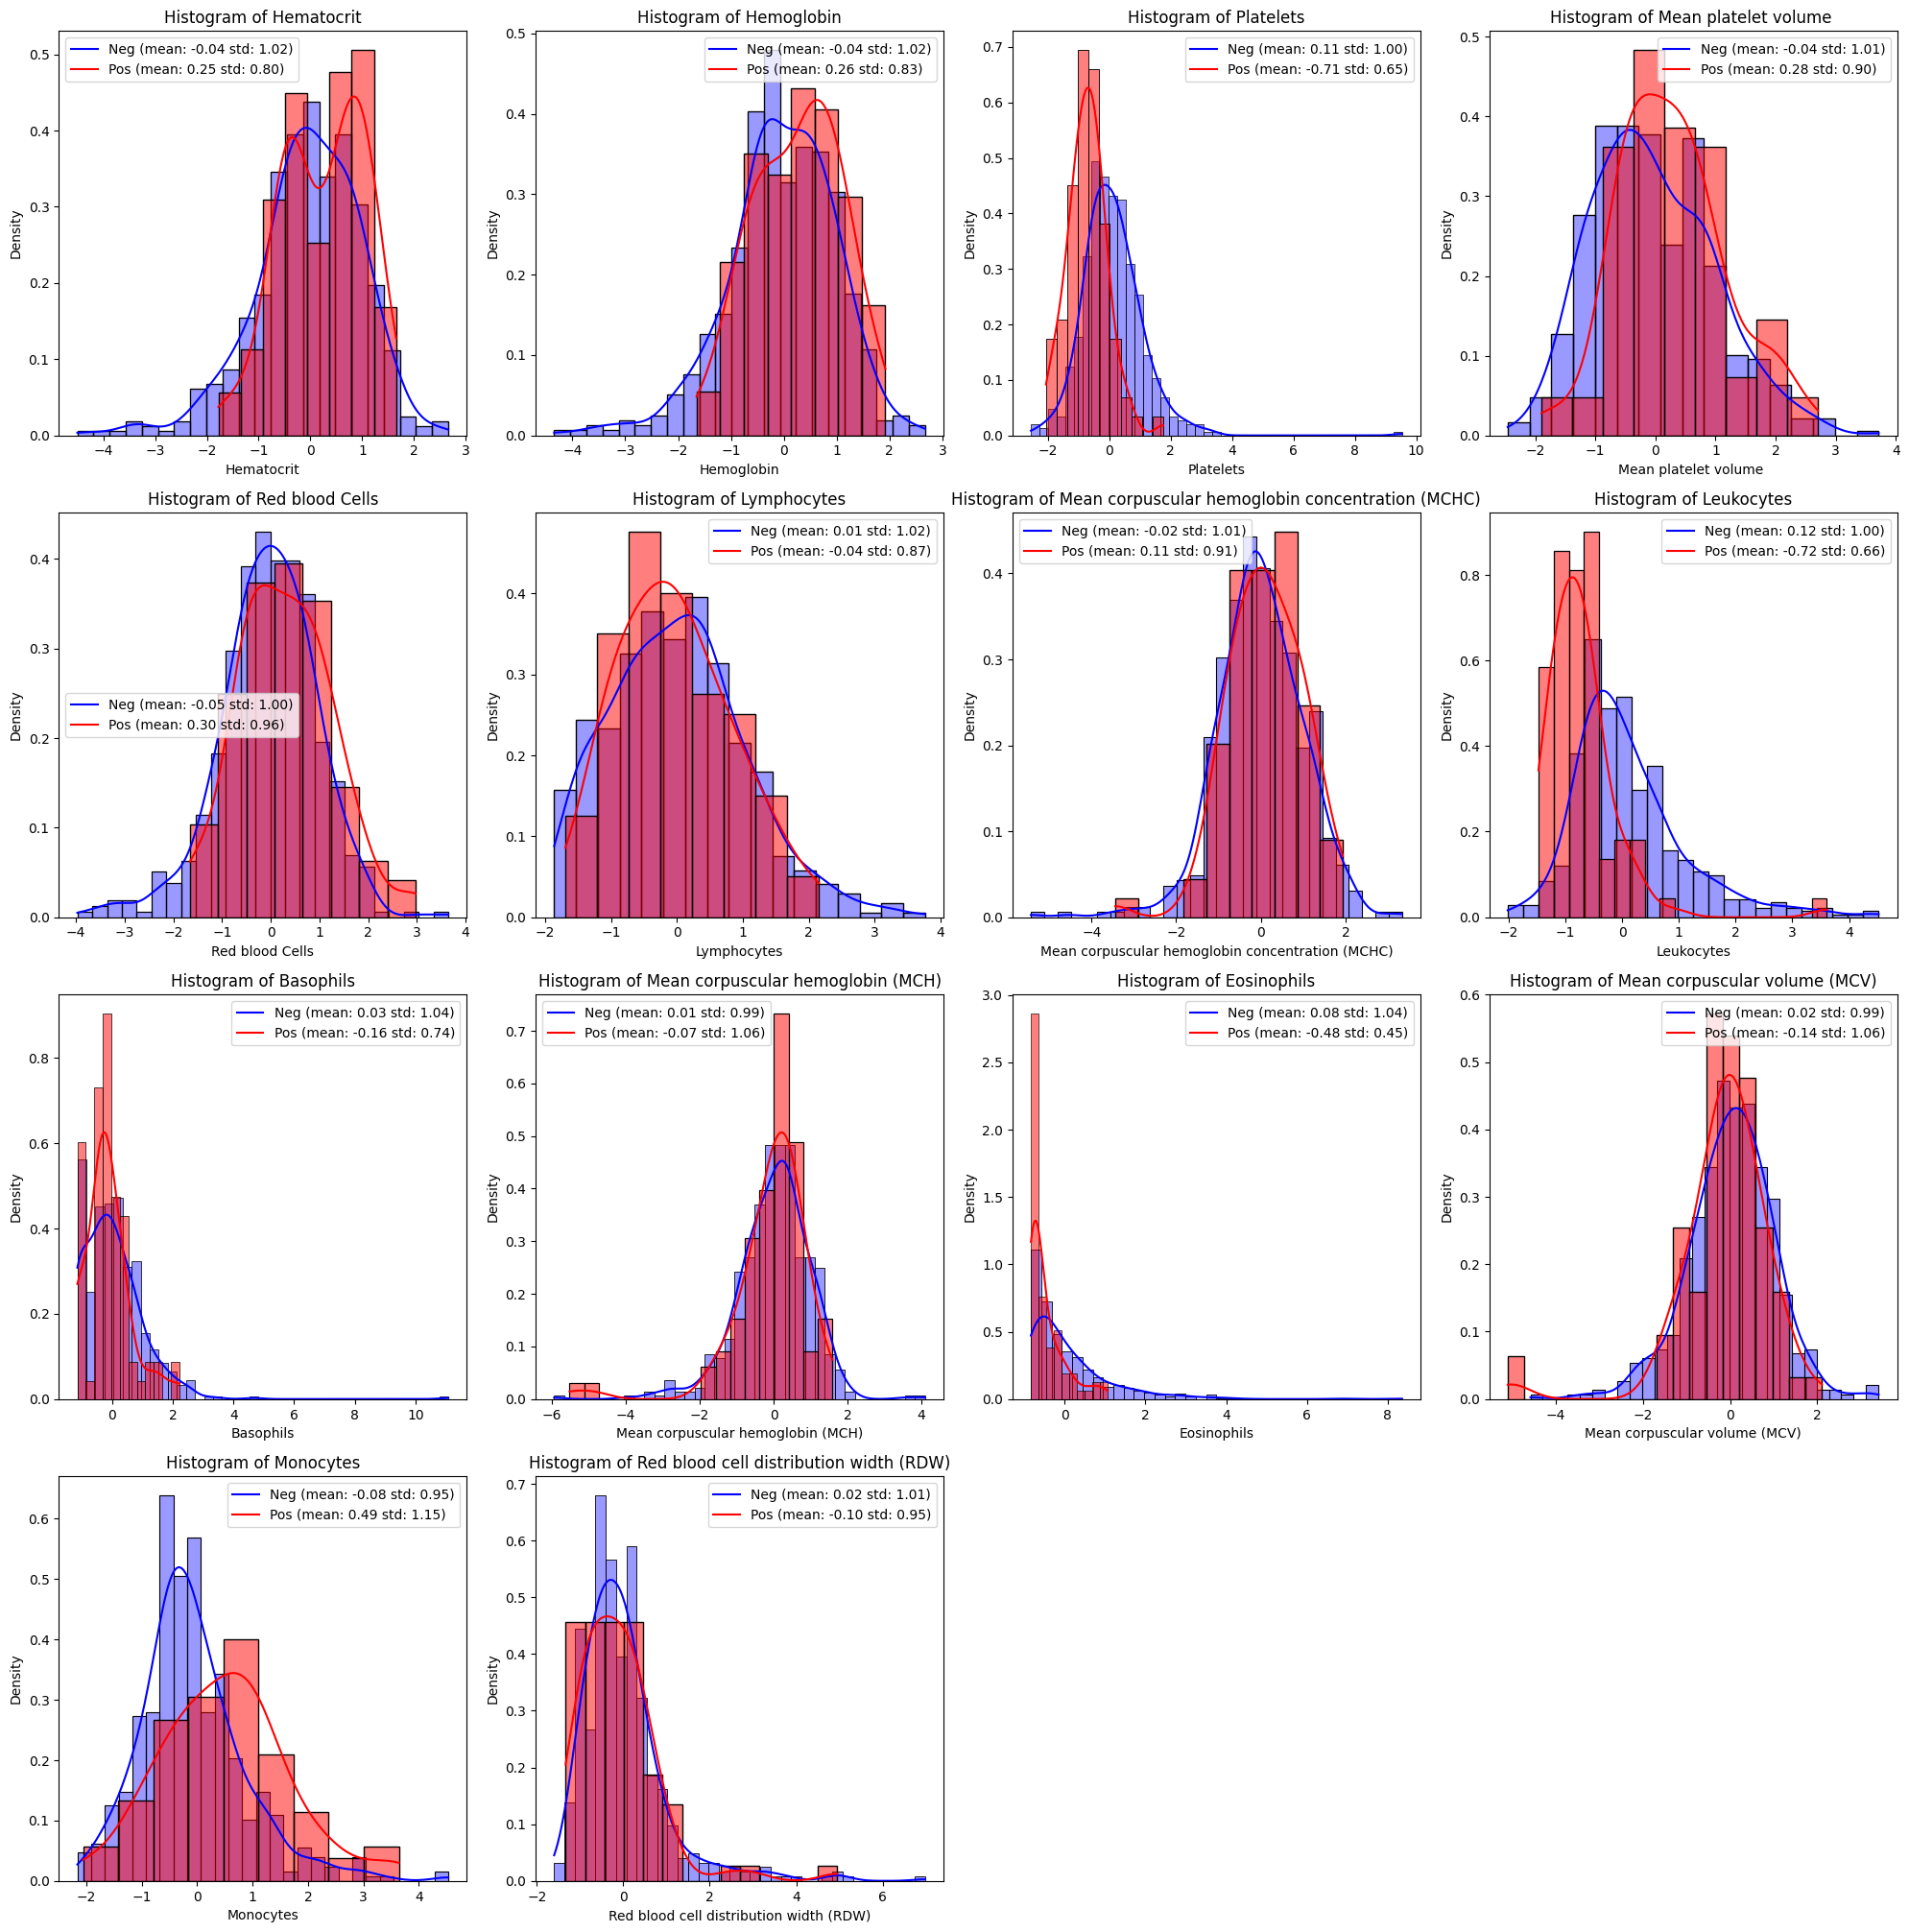

In [ ]:
n_rows = blood_df.columns.shape[0]
plt.figure(figsize=(20, n_rows*5))
for index, column in enumerate(blood_df.columns):
    plt.subplot(n_rows, 4, index + 1)
    sns.histplot(negative_df[column], kde=True, color='Blue', label='Negative', stat='density', alpha=0.4)
    sns.histplot(positive_df[column], kde=True, color='Red', label='Positive', stat='density', alpha=0.5)
    plt.title(f'Histogram of {column}')
    plt.legend(labels=[f'Neg (mean: {negative_df[column].mean():.2f} std: {negative_df[column].std():.2f})', f'Pos (mean: {positive_df[column].mean():.2f} std: {positive_df[column].std():.2f})'])
plt.tight_layout()
# df[['covid', 'Hemoglobin']].groupby('covid').head()

### Object: viral analysis

In [28]:
viral_df = df[df.columns[df.dtypes=='O']].__deepcopy__()
viral_df.columns

Index(['Patient ID', 'covid', 'Respiratory Syncytial Virus', 'Influenza A',
       'Influenza B', 'Parainfluenza 1', 'CoronavirusNL63',
       'Rhinovirus/Enterovirus', 'Coronavirus HKU1', 'Parainfluenza 3',
       'Chlamydophila pneumoniae', 'Adenovirus', 'Parainfluenza 4',
       'Coronavirus229E', 'CoronavirusOC43', 'Inf A H1N1 2009',
       'Bordetella pertussis', 'Metapneumovirus', 'Parainfluenza 2',
       'Influenza B, rapid test', 'Influenza A, rapid test'],
      dtype='object')

In [29]:
for col in viral_df.columns:
  print(f' {col:-<50} {df[col].unique()}')

 Patient ID---------------------------------------- ['44477f75e8169d2' '126e9dd13932f68' 'a46b4402a0e5696' ...
 '5c57d6037fe266d' 'c20c44766f28291' '2697fdccbfeb7f7']
 covid--------------------------------------------- ['negative' 'positive']
 Respiratory Syncytial Virus----------------------- [nan 'not_detected' 'detected']
 Influenza A--------------------------------------- [nan 'not_detected' 'detected']
 Influenza B--------------------------------------- [nan 'not_detected' 'detected']
 Parainfluenza 1----------------------------------- [nan 'not_detected' 'detected']
 CoronavirusNL63----------------------------------- [nan 'not_detected' 'detected']
 Rhinovirus/Enterovirus---------------------------- [nan 'detected' 'not_detected']
 Coronavirus HKU1---------------------------------- [nan 'not_detected' 'detected']
 Parainfluenza 3----------------------------------- [nan 'not_detected' 'detected']
 Chlamydophila pneumoniae-------------------------- [nan 'not_detected' 'detected']
 

#### Viral Count in Pie

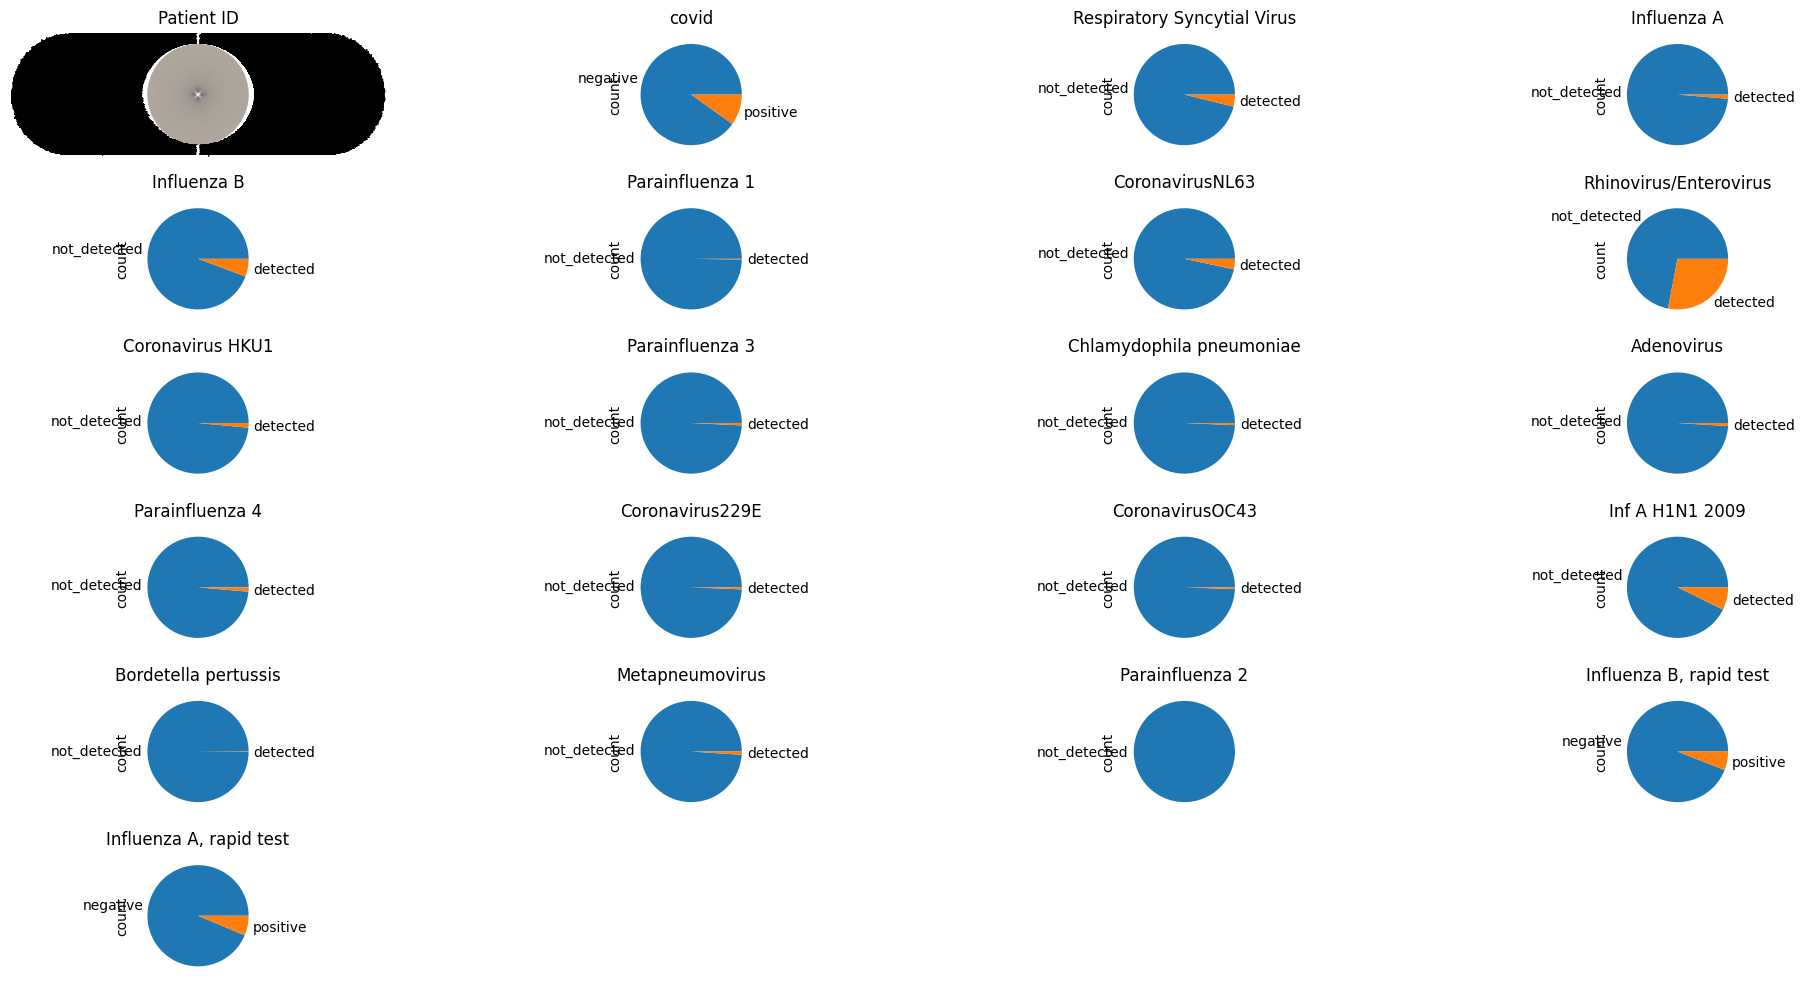

In [36]:
plt.figure(figsize=(20,10))
for index, data in enumerate(viral_df):
  plt.subplot(6, 4, index+1)
  plt.title(data)
  viral_df[data].value_counts().plot.pie()
plt.tight_layout()

- On remarque que beaucoup de personne ont le Rhinovirus

#### Viral vs Target (Covid)

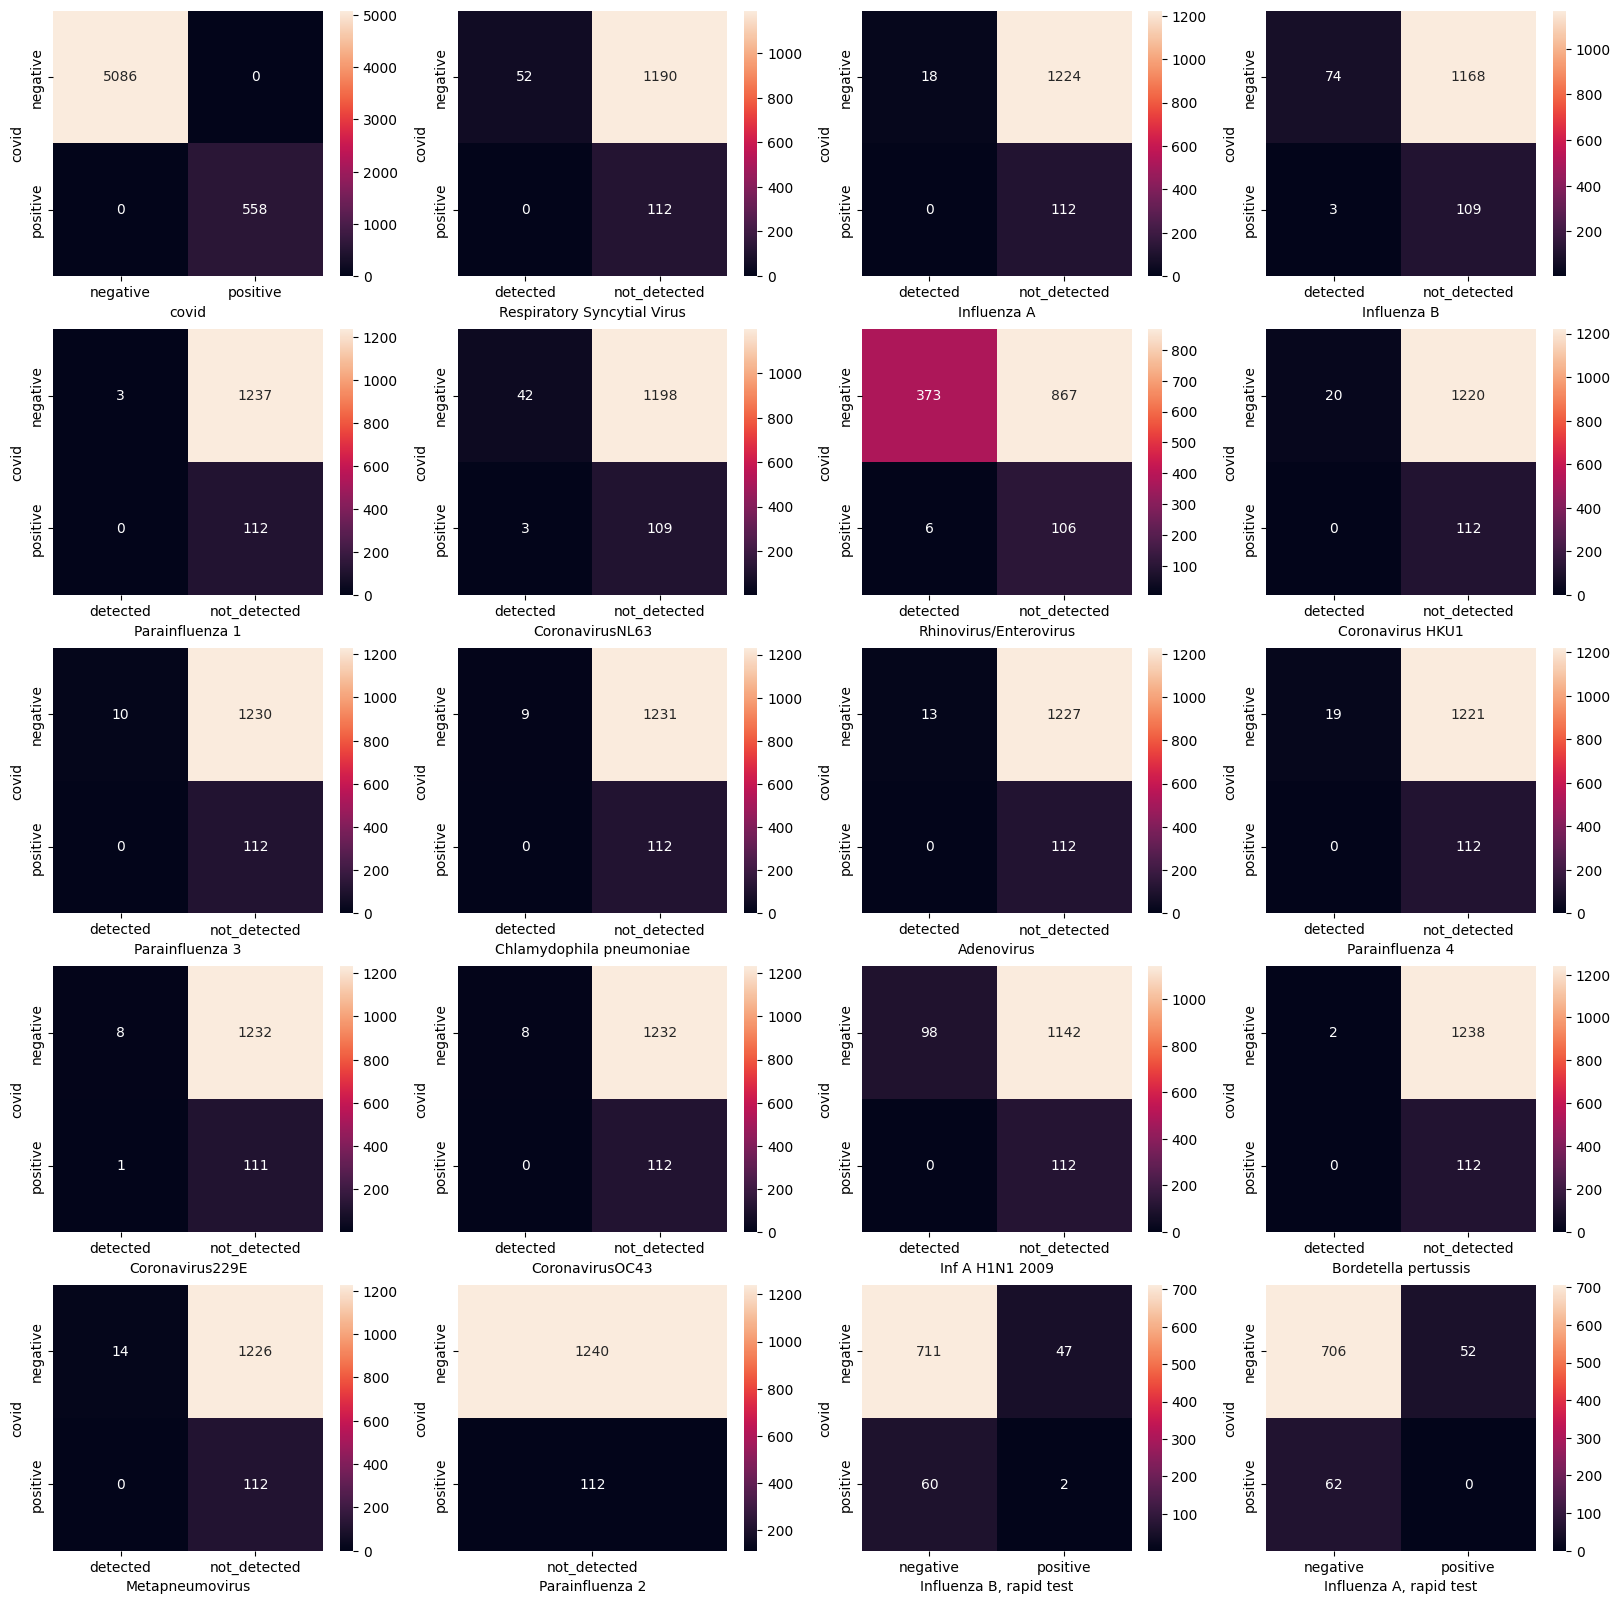

In [ ]:
plt.figure(figsize=(20,20))
for index, col in enumerate(viral_df):
  plt.subplot(5, 4, index+1)
  sns.heatmap(pd.crosstab(df['covid'], df[col]), annot=True, fmt='d')

- On peut en déduire que quand on est positif au covid, on a de forte chance d'être négatifs aux autres maladies, car c'est assez rare (mais pas impossible) d'être testé positivement à deux virus en même temps. 
- Par contre, on a déjà observé qu'il était possible d'avoir jusque trois virus détecté sur un même patient dans notre dataset.

### Advanced Analysis

#### Correlation between each blood test

<Axes: >

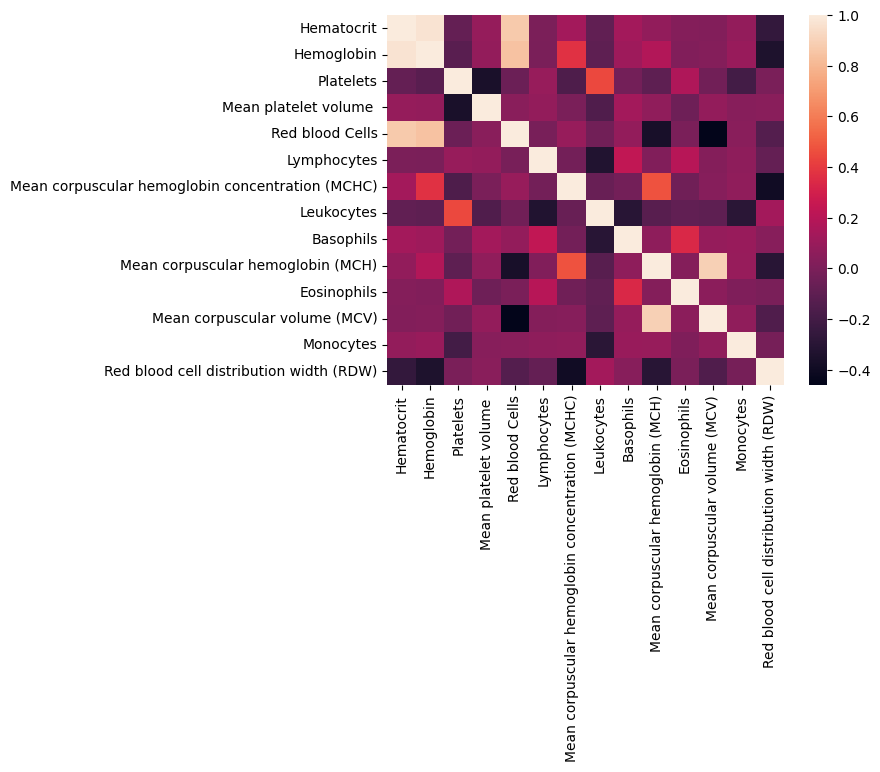

In [33]:
# Find columns with inf or nan correlation values
sns.heatmap(blood_df.corr())

#### Age/Blood Relation

In [ ]:
print(blood_df.columns.shape)
for i, e in enumerate(blood_df.columns):
  print(i, e)

(14,)
0 Hematocrit
1 Hemoglobin
2 Platelets
3 Mean platelet volume 
4 Red blood Cells
5 Lymphocytes
6 Mean corpuscular hemoglobin concentration (MCHC)
7 Leukocytes
8 Basophils
9 Mean corpuscular hemoglobin (MCH)
10 Eosinophils
11 Mean corpuscular volume (MCV)
12 Monocytes
13 Red blood cell distribution width (RDW)


In [32]:
#Analyse de sang par age, regression en fonction de negatif ou positif, aucun lien
# for index, col in enumerate(blood_df.columns):
#   plt.figure()
#   sns.lmplot(df, x='Patient age quantile', y=col, hue='covid')
# plt.tight_layout()

In [ ]:
# Avec ça on s'assure qu'il n'y a aucune relation entre les analyses de sang et l'age
df.corr(numeric_only=True)['Patient age quantile'].sort_values()

Leukocytes                                         -0.166386
Platelets                                          -0.158683
Lymphocytes                                        -0.125935
Mean corpuscular hemoglobin concentration (MCHC)   -0.124671
Red blood Cells                                    -0.037510
Intensive Care Unit                                -0.035772
Semi-Intensive Care Unit                            0.015736
Eosinophils                                         0.022085
Regular Care Unit                                   0.046166
Monocytes                                           0.050962
Hemoglobin                                          0.060320
Hematocrit                                          0.096808
Basophils                                           0.107525
Mean platelet volume                                0.119449
Red blood cell distribution width (RDW)             0.166429
Mean corpuscular hemoglobin (MCH)                   0.197394
Mean corpuscular volume 

In [ ]:
#on perd trop de data si on dropna car entre les catégories de test (viral and blood) pas les mêmes valeurs manquantes
blood_df.count()

Hematocrit                                          603
Hemoglobin                                          603
Platelets                                           602
Mean platelet volume                                599
Red blood Cells                                     602
Lymphocytes                                         602
Mean corpuscular hemoglobin concentration (MCHC)    602
Leukocytes                                          602
Basophils                                           602
Mean corpuscular hemoglobin (MCH)                   602
Eosinophils                                         602
Mean corpuscular volume (MCV)                       602
Monocytes                                           601
Red blood cell distribution width (RDW)             602
dtype: int64

In [ ]:
viral_df.count()

covid                          5644
Respiratory Syncytial Virus    1354
Influenza A                    1354
Influenza B                    1354
Parainfluenza 1                1352
CoronavirusNL63                1352
Rhinovirus/Enterovirus         1352
Coronavirus HKU1               1352
Parainfluenza 3                1352
Chlamydophila pneumoniae       1352
Adenovirus                     1352
Parainfluenza 4                1352
Coronavirus229E                1352
CoronavirusOC43                1352
Inf A H1N1 2009                1352
Bordetella pertussis           1352
Metapneumovirus                1352
Parainfluenza 2                1352
Influenza B, rapid test         820
Influenza A, rapid test         820
dtype: int64

### Vérification des hypothèses: Test de student

In [ ]:
from scipy.stats import ttest_ind

In [ ]:
negative_balanced = negative_df.sample(positive_df.shape[0])

In [ ]:
def test(col):
  alpha = 0.02
  stat, p = ttest_ind(negative_balanced[col].dropna(), positive_df[col].dropna())
  if p < alpha:
    return 'H0 Rejetée'
  else:
    return 0

In [ ]:
for col in blood_df.columns:
  print(f'{col :-<50} {test(col)}')

Hematocrit---------------------------------------- 0
Hemoglobin---------------------------------------- 0
Platelets----------------------------------------- H0 Rejetée
Mean platelet volume ----------------------------- H0 Rejetée
Red blood Cells----------------------------------- H0 Rejetée
Lymphocytes--------------------------------------- 0
Mean corpuscular hemoglobin concentration (MCHC)-- 0
Leukocytes---------------------------------------- H0 Rejetée
Basophils----------------------------------------- 0
Mean corpuscular hemoglobin (MCH)----------------- 0
Eosinophils--------------------------------------- H0 Rejetée
Mean corpuscular volume (MCV)--------------------- 0
Monocytes----------------------------------------- H0 Rejetée
Red blood cell distribution width (RDW)----------- 0


### Conclusion student

- On remarque avec le test de student que notre hypothèse nulle est rejtetée pour 6 tests sanguins. On peut en déduire que les moyennes de ces tests pour les cas positifs et négatifs sont sensiblement différents, et qu'il pourrait donc y avoir un lien entre positif au covid et taux de plaquettes, globules rouges, globules blanc, etc.

# Conclusion EDA

I - Analyse de la forme:
* Identification de la target:  
    * SARS-Cov-2 exam result
* Nombre des lignes et de colonnes 
    * (5644, 39)
* Identification des valeurs manquantes 
    * Patient ID, Patient age quantile, SARS-Cov-2 exam result aucune valeur manquante
    * Le reste commence à 76% de valeur manquante
    * Puis groupe à 85% et 89% de valeur manquante
    * Puis le reste au dessus 90% de valeur manquante (à supprimer certainement)
* Types de variables
    * Object
    * Float
    * Int

II - Analyse du fond:
* Visualisation de la target (histogramme/boxplot)
    * 5086 covid negatif
    * 558 covid positif
    * On remarque age assez linéaire, plus d’enfant, de moyen age et de très agé mais globalement uniforme
* Compréhension des différentes variables (recherche)
    * Variable d’analyse de sang
        * On remarque que tout est normalisé (moyenne 0 et std 1)
        * eosiphils assez elevé vers 0, pas de négatif
        * pareil pour basophils
    * Variable d’analyse de virus
        * Relativement faible detection d’autre maladie chez les patients
        * Rhinovirus très élevé
        * h1n1 et influenza B un petit plus élevé que les autres
* Visualisation des relations : features/target
    * Variable d’analyse de sang (malade vs pas malade)
        * Hematocrit et hemoglobin généralement plus élevé et moins dispersé chez malade
        * Platelets très faible chez malade
        * Globule rouge élevé et Globule blanc un peu plus faible chez malade
        * Leukocytes très faible chez malade
        * Basophils assez faible chez malade
        * Eosinophils très faible chez malade
        * MCV un peu faible chez malade
        * Monocytes plus élevé chez malade en moyenne (bcp de sain aux alentours des moyennes nationale)
        * Serum glucose assez faible chez malade
    * Variable d’analyse de virus
        * bcp de gens on rhynovirus, et certains l’ont en même temps que covid, ça veut ptet rien dire
* Analyse avancée des relations:
    * Forte correlation entre certaines analyse de sang (hematocrit, hemoglobin etc)
    * Aucune corrélation forte entre age et analyse de sang
    * Valeurs manquantes différentes entre tests de sang et virus, donc séparer les deux
*  Identification des outliers

Test de nos hypothèses d’analyse de sang : *Leukocytes*, *Monocytes* et *Eosinophils* différent entre malade et pas malade

Pour ça, on fait un test de student avec Hypothèse nulle **H0 = Moyenne des analyse de sang entre malade et pas malade EGALES**

* Objectif : Rejeter l’hypothèse pour chaque analyse de sang définie comme différente à la base

    * Si p-value en dessous d’un pourcentage alpha (2%-5%) alors on rejette l’hypothèse, sinon on peut pas la rejeter (mais ça veut pas dire qu’elle est vraie)